### Extract Resp Features over 5 Second Blocks and Create Feature Matrix

In [20]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path


## Valence Feature Creation

### AIM1 Paths (Valence Only)

In [21]:
# ======================================================
# Respiration + BORIS paths (VALENCE SETS ONLY)
# ======================================================

# Base paths for valence data
valence_h5_base = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\Resp_h5"
valence_boris_base = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\boris_csv_RI1 and RI2"

# --- Valence (RI1, RI2, BLRI) ---
# Using relative paths from base; adjust file names as needed
resp_paths_valence = {
    "RI1_3_6": os.path.join(valence_h5_base, "RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"),
    "RI2_3_6": os.path.join(valence_h5_base, "RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"),
    "RI1_4_7": os.path.join(valence_h5_base, "RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"),
    "RI2_4_7": os.path.join(valence_h5_base, "RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"),
    "RI1_2_3": os.path.join(valence_h5_base, "RI1_s2_3_p5_3_nRB3_20250622_104059_merged.h5"),
    "RI2_2_3": os.path.join(valence_h5_base, "RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"),
    "RI1_4_8": os.path.join(valence_h5_base, "RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"),
    "RI2_4_8": os.path.join(valence_h5_base, "RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"),
    "RI1_1_1": os.path.join(valence_h5_base, "RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"),
    "RI2_1_1": os.path.join(valence_h5_base, "RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"),
    "RI1_1_2": os.path.join(valence_h5_base, "RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"),
    "RI2_1_2": os.path.join(valence_h5_base, "RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"),
    "RI1_2_4": os.path.join(valence_h5_base, "RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"),
    "RI2_2_4": os.path.join(valence_h5_base, "RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"),
    "RI1_3_5": os.path.join(valence_h5_base, "RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"),
    "RI2_3_5": os.path.join(valence_h5_base, "RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"),
    # Baseline recordings (pre-valence)
    "BLRI_1_1": os.path.join(valence_h5_base, "BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5"),
    "BLRI_1_2": os.path.join(valence_h5_base, "BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5"),
    "BLRI_2_3": os.path.join(valence_h5_base, "BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5"),
    "BLRI_2_4": os.path.join(valence_h5_base, "BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5"),
    "BLRI_3_6": os.path.join(valence_h5_base, "BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"),
    "BLRI_4_7": os.path.join(valence_h5_base, "BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"),
    "BLRI_4_8": os.path.join(valence_h5_base, "BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5"),
}

boris_paths_valence = {
    "RI1_3_6": os.path.join(valence_boris_base, "RI1_s3_6_p5_3_nRB3_HEEPS.csv"),
    "RI2_3_6": os.path.join(valence_boris_base, "RI2_s3_6_p_5_3_nRB3_2025062.csv"),
    "RI1_4_7": os.path.join(valence_boris_base, "RI1_s4_7_p5_2_nRB3_HEEPS.csv"),
    "RI2_4_7": os.path.join(valence_boris_base, "RI2_s4_7_p5_2_nRB3_HEEPS.csv"),
    "RI1_2_3": os.path.join(valence_boris_base, "RI1_s2_3_p5_3_nRB3_20250622_104059_ss.csv"),
    "RI2_2_3": os.path.join(valence_boris_base, "RI2_s2_3_p5_3_nRB3_20250622_1102116.1_ss.csv"),
    "RI1_4_8": os.path.join(valence_boris_base, "RI1_s4_8_p5_1_nRB3_HEEPS.csv"),
    "RI2_4_8": os.path.join(valence_boris_base, "RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv"),
    "RI1_1_1": os.path.join(valence_boris_base, "RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv"),
    "RI2_1_1": os.path.join(valence_boris_base, "RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv"),
    "RI1_1_2": os.path.join(valence_boris_base, "RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv"),
    "RI2_1_2": os.path.join(valence_boris_base, "RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv"),
    "RI1_2_4": os.path.join(valence_boris_base, "RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv"),
    "RI2_2_4": os.path.join(valence_boris_base, "RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv"),
    "RI2_3_5": os.path.join(valence_boris_base, "RI2_s3_5_p5_4_nRB3_20250621.csv"),
}

### Recordings and Files Available

Will need to drop RI1_3_5

In [22]:
# ======================================================
# Summary check (VALENCE ONLY)
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

# ======================================================
# Organized summaries by experiment type (VALENCE ONLY)
# ======================================================

# --- Split out valence subsets for clarity ---
resp_paths_interactions = {k: v for k, v in resp_paths_valence.items() if k.startswith(("RI1", "RI2"))}
resp_paths_blri = {k: v for k, v in resp_paths_valence.items() if k.startswith("BLRI")}

# Filter BORIS dicts by matching prefixes
boris_paths_valence = {k: v for k, v in boris_paths_valence.items() if k.startswith(("RI1", "RI2"))}

summarize_paths(resp_paths_valence, boris_paths_valence, "Valence (RI1/RI2)")

print(f"\nTotal respiration files (valence only): {len(resp_paths_valence)}")
print(f"Total BORIS files (valence only): {len(boris_paths_valence)}")

# Note: BLRI (pre-valence baseline) processing will be attempted but skipped if missing
print(f"\nPre-valence Baseline (BLRI) files available: {len(resp_paths_blri)}")


 Valence (RI1/RI2) summary
Resp files: 23 | BORIS files: 15 | No BORIS: 8
Missing trials: BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8, RI1_3_5

Total respiration files (valence only): 23
Total BORIS files (valence only): 15

Pre-valence Baseline (BLRI) files available: 7


Rank Map is used to construct feature matrix but will not be available during training

In [23]:
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

# 100 Hz Fails in BreathMetrics
## Main failure (division by zero)

In `findExtrema()`, window sizes depend on sampling rate:

```python
srateAdjust = srate / 1000
swSizes = [floor(5 * srateAdjust), ...]
```

At 100 Hz:

```python
srateAdjust = 0.1 → swSizes = [0, 1, 2, 5]
```

This creates:

```python
sw = 0 → len(signal) / sw → division by zero
```

This is a direct code-level failure.

---

## High Sampling Rates are necessary to capture breaths

Later in `estimateSecondaryFeatures()`:
breathing rate is the sampling rate over the average number of samples in between breaths.
```python
breathingRate = srate / mean(breathDiffs)
```

At 100 Hz, peak detection may be less reliable, which means fewer valid breaths are found and `breathDiffs` becomes small or empty. This leads to:

```python
mean(breathDiffs) ≈ 0 → division by zero / NaNs
```


Trial: RI1_3_6
  → 200 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
  ⚠️  bmObject fitting failed: zero-size array to reduction operation maximum which has no identity
bm failed
  → 400 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  n_breaths=3902, resp_rate=6.47 Hz
  → 500 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  n_breaths=3900, resp_rate=6.47 Hz
  → 600 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  n_breaths=3902, resp_rate=6.41 Hz
  → 700 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  n_breaths=3906, resp_rate=6.35 Hz
  → 1000 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
exp

,trial,rate_hz,n_breaths,breathing_rate_hz,mean_inhale_dur_sec,mean_exhale_dur_sec,mean_tidal_vol,ie_ratio
0,RI1_3_6,400,3902,6.473534,0.063943,0.072327,99454.208705,0.884080
1,RI1_3_6,500,3900,6.474808,0.064999,0.072280,99719.001254,0.899272
2,RI1_3_6,600,3902,6.411162,0.066268,0.073402,100999.367671,0.902815
3,RI1_3_6,700,3906,6.352899,0.066792,0.074299,102119.498613,0.898960
4,RI1_3_6,1000,3899,6.470977,0.067001,0.072650,100147.602206,0.922243
5,RI2_3_6,400,2506,4.116342,0.129189,0.087965,104369.199015,1.468639
6,RI2_3_6,500,2512,4.118703,0.131834,0.088132,104741.844719,1.495871
7,RI2_3_6,600,2508,4.076356,0.133351,0.088476,105807.699352,1.507191
8,RI2_3_6,700,2508,4.034522,0.133938,0.089694,106754.504831,1.493274
9,RI2_3_6,1000,2511,4.119610,0.133401,0.088035,104724.060258,1.515310


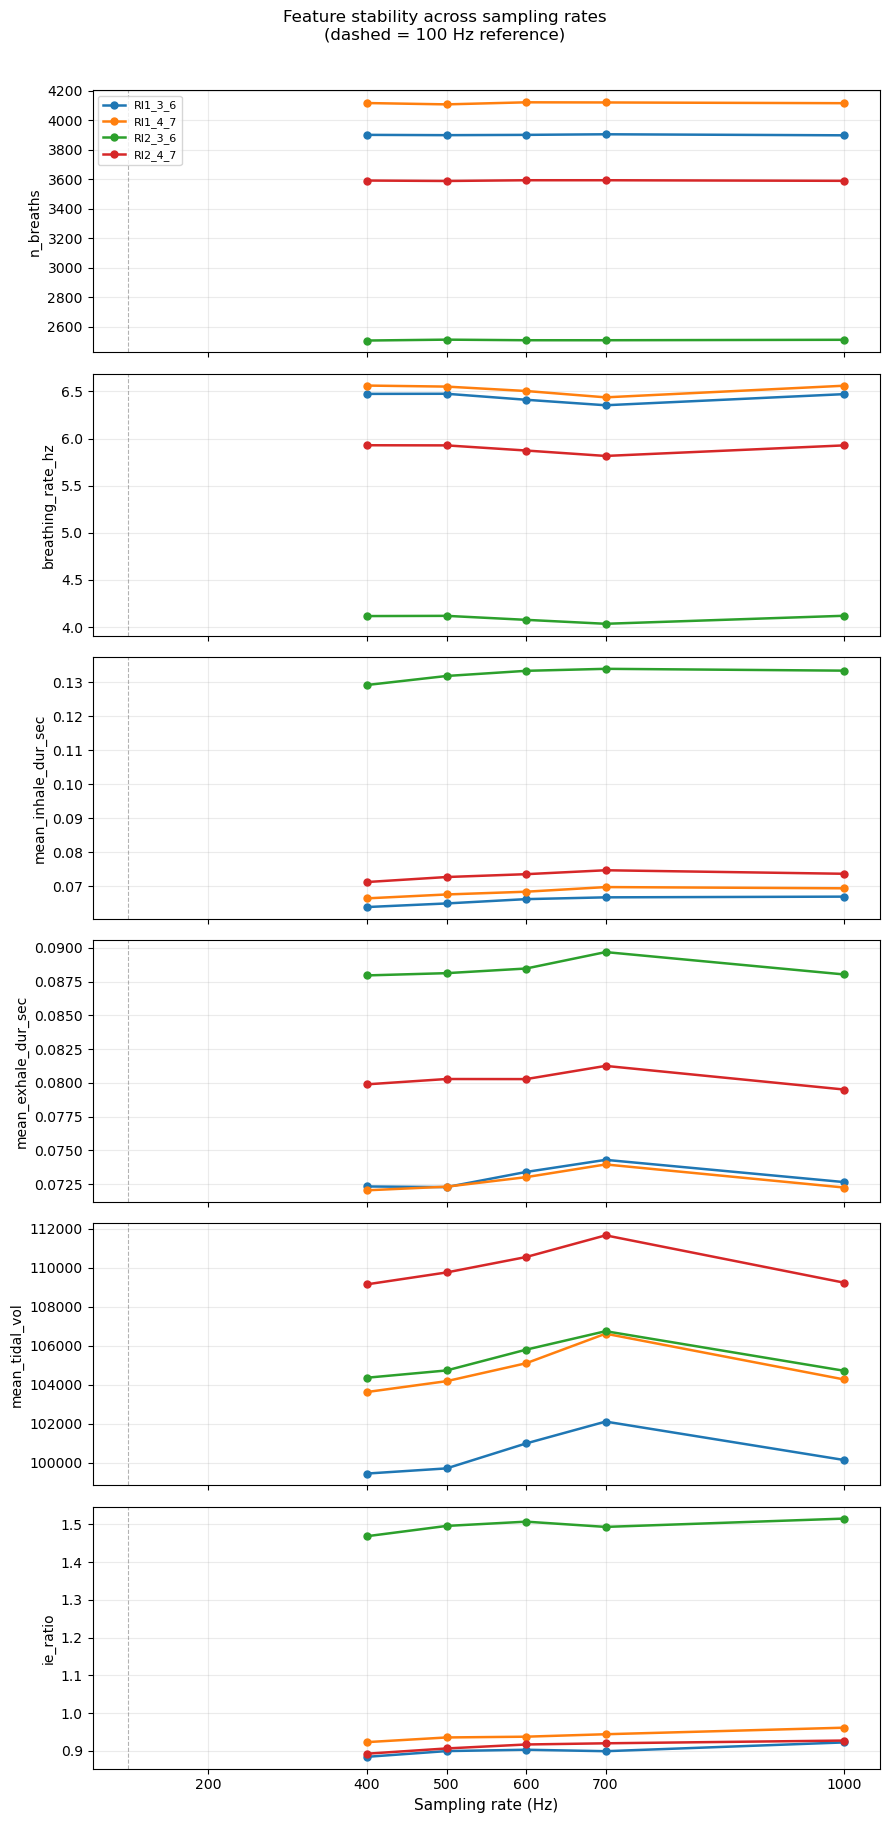


── % deviation from highest-rate estimate (per trial) ──

n_breaths:
trial    RI1_3_6  RI1_4_7  RI2_3_6  RI2_4_7
rate_hz                                    
400          0.1      0.0      0.2      0.1
500          0.0      0.2      0.0      0.0
600          0.1      0.1      0.1      0.1
700          0.2      0.1      0.1      0.1
1000         0.0      0.0      0.0      0.0

breathing_rate_hz:
trial    RI1_3_6  RI1_4_7  RI2_3_6  RI2_4_7
rate_hz                                    
400          0.0      0.0      0.1      0.0
500          0.1      0.1      0.0      0.0
600          0.9      0.9      1.0      0.9
700          1.8      1.9      2.1      1.9
1000         0.0      0.0      0.0      0.0

mean_inhale_dur_sec:
trial    RI1_3_6  RI1_4_7  RI2_3_6  RI2_4_7
rate_hz                                    
400          4.6      4.3      3.2      3.3
500          3.0      2.6      1.2      1.3
600          1.1      1.4      0.0      0.2
700          0.3      0.5      0.4      1.4
1000    

In [24]:
# ============================================================
# Sampling Rate Sweep — Feature Stability Diagnostic
# ============================================================
# Runs load_clean_resp_signal + fit_bm_session at multiple
# target_srate values for a handful of recordings, then plots
# how key features change across rates.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# ── Config ──────────────────────────────────────────────────
RATES_TO_TEST  = [200, 400, 500, 600, 700, 1000]   # Hz
N_TEST_FILES   = 4                                # how many recordings to sweep

# Pick a handful of your actual files — works with either dict
test_paths = dict(list(resp_paths_interactions.items())[:N_TEST_FILES])

# Features to track (subset for readability; add more as needed)
TRACK_FEATURES = [
    "n_breaths",
    "breathing_rate_hz",
    "mean_inhale_dur_sec",
    "mean_exhale_dur_sec",
    "mean_tidal_vol",
    "ie_ratio",
]

# ── Sweep ───────────────────────────────────────────────────
results = []   # list of dicts: {trial, rate, feature: value, ...}

for trial, h5_path in test_paths.items():
    print(f"\n{'='*55}")
    print(f"Trial: {trial}")

    for rate in RATES_TO_TEST:
        print(f"  → {rate} Hz ...", end=" ", flush=True)
        try:
            signal, time, fs, meta = load_clean_resp_signal(h5_path, target_rate=rate)
            if signal is None:
                print("load failed"); continue

            bm = fit_bm_session(signal, fs, data_type="rodentAirflow")
            if bm is None:
                print("bm failed"); continue

            # Use the full session as one "bout" to get aggregate features
            feats = extract_bout_features(bm, time[0], time[-1])
            if feats is None:
                print("no breaths detected"); continue

            row = {"trial": trial, "rate_hz": rate}
            row.update({k: feats[k] for k in TRACK_FEATURES if k in feats})
            results.append(row)
            print(f"✓  n_breaths={feats['n_breaths']}, "
                  f"resp_rate={feats['breathing_rate_hz']:.2f} Hz")

        except Exception as e:
            print(f"ERROR: {e}")

sweep_df = pd.DataFrame(results)
print(f"\n✅ Sweep complete: {len(sweep_df)} rows")
display(sweep_df)

# ── Plot ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure rates are sorted for clean spacing
RATES_TO_TEST = sorted(RATES_TO_TEST)

n_feats  = len(TRACK_FEATURES)
n_trials = sweep_df["trial"].nunique()
colors   = plt.cm.tab10.colors

fig, axes = plt.subplots(
    n_feats, 1,
    figsize=(9, 3 * n_feats),
    sharex=True
)

# handle case where there's only one feature
if n_feats == 1:
    axes = [axes]

for ax, feat in zip(axes, TRACK_FEATURES):
    for i, (trial, grp) in enumerate(sweep_df.groupby("trial")):
        grp_sorted = grp.sort_values("rate_hz")
        ax.plot(
            grp_sorted["rate_hz"], grp_sorted[feat],
            marker="o", linewidth=1.8, markersize=5,
            color=colors[i % len(colors)],
            label=trial
        )

    ax.set_ylabel(feat, fontsize=10)

    # ✅ EVENLY SPACED TICKS (no log scale)
    ax.set_xticks(RATES_TO_TEST)
    ax.set_xticklabels([str(r) for r in RATES_TO_TEST])

    ax.axvline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.25)

axes[0].legend(fontsize=8, loc="upper left")
axes[-1].set_xlabel("Sampling rate (Hz)", fontsize=11)

fig.suptitle(
    "Feature stability across sampling rates\n(dashed = 100 Hz reference)",
    fontsize=12, y=1.01
)

plt.tight_layout()
plt.show()


# ── Stability summary: % change from max rate ────────────────
# Compares each rate against the highest rate tested as a "ground truth"
print("\n── % deviation from highest-rate estimate (per trial) ──")

ref_rate = max(RATES_TO_TEST)

for feat in TRACK_FEATURES:
    deviations = []

    for trial, grp in sweep_df.groupby("trial"):
        ref_val = grp.loc[grp["rate_hz"] == ref_rate, feat].values

        if len(ref_val) == 0 or np.isnan(ref_val[0]) or ref_val[0] == 0:
            continue

        for _, row in grp.iterrows():
            pct = 100 * abs(row[feat] - ref_val[0]) / abs(ref_val[0])
            deviations.append({
                "trial": trial,
                "rate_hz": row["rate_hz"],
                "feature": feat,
                "pct_dev": pct
            })

    if not deviations:
        continue

    dev_df = pd.DataFrame(deviations)

    pivot = dev_df.pivot_table(
        index="rate_hz",
        columns="trial",
        values="pct_dev",
        aggfunc="mean"
    )

    print(f"\n{feat}:")
    print(pivot.round(1).to_string())


Trial: RI1_3_6
  → 100 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
  ⚠️  bmObject fitting failed: division by zero
bm failed
  → 200 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
  ⚠️  bmObject fitting failed: zero-size array to reduction operation maximum which has no identity
bm failed
  → 400 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  8 bouts, 2/5 features have NaNs
  → 500 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  8 bouts, 2/5 features have NaNs
  → 600 Hz ... original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
✓  8 bouts, 2/5 features have NaNs
  → 1000 Hz ... original resp len: 12065446
original fs: 20000.0
duration_se

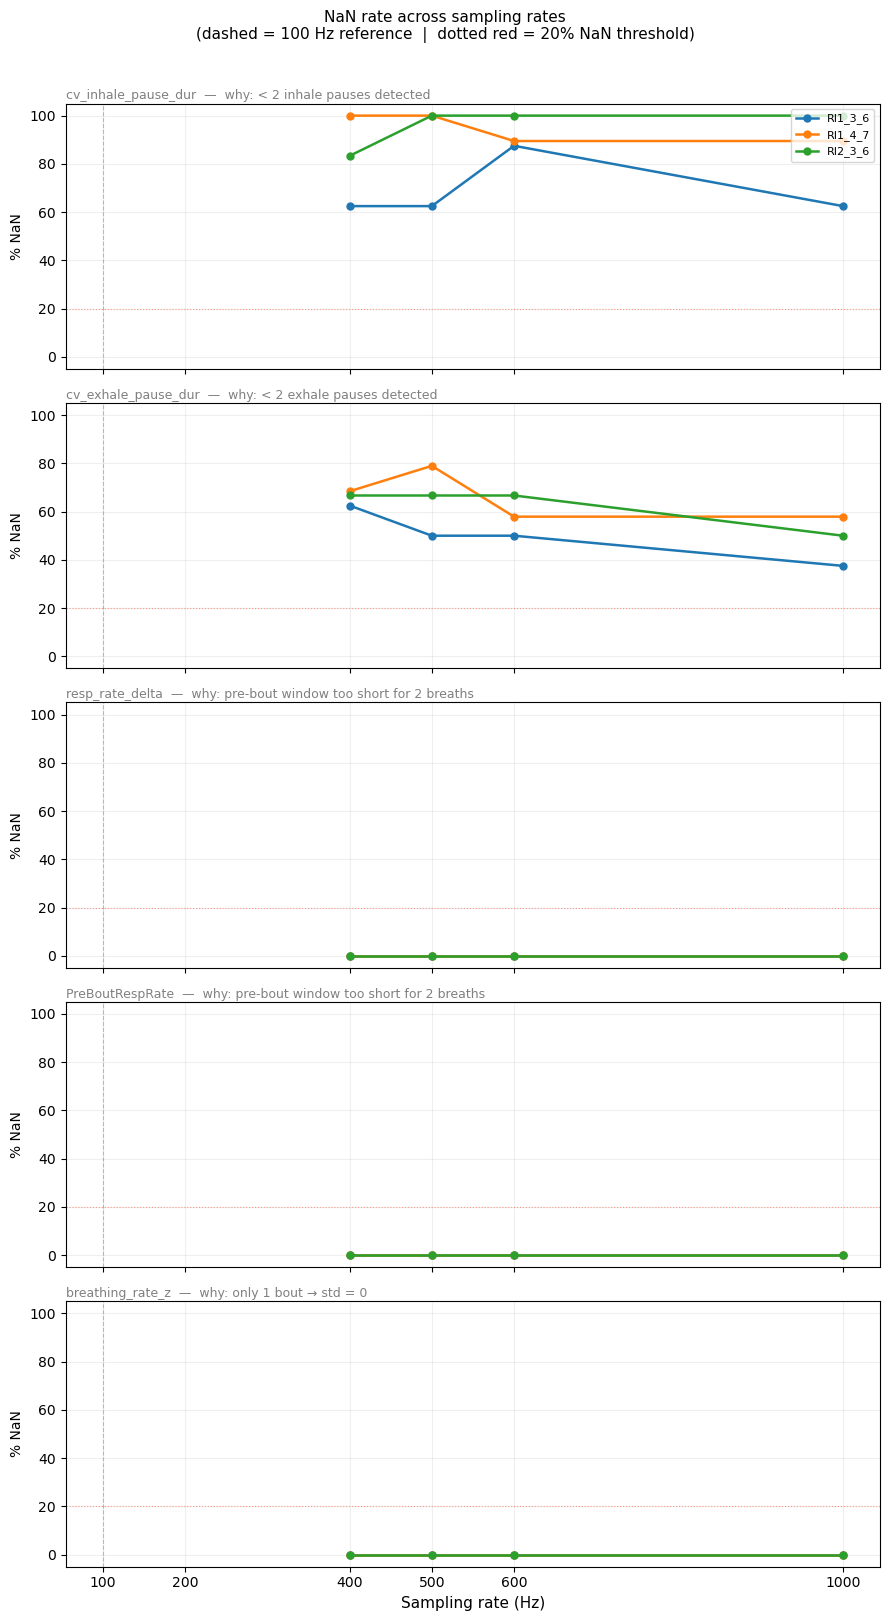


── Mean % NaN by feature × sampling rate (averaged across trials) ──

rate_hz              400   500   600   1000
cv_inhale_pause_dur  81.9  87.5  92.3  84.0

rate_hz              400   500   600   1000
cv_exhale_pause_dur  65.9  65.2  58.2  48.5

rate_hz          400   500   600   1000
resp_rate_delta   0.0   0.0   0.0   0.0

rate_hz          400   500   600   1000
PreBoutRespRate   0.0   0.0   0.0   0.0

rate_hz           400   500   600   1000
breathing_rate_z   0.0   0.0   0.0   0.0


── Bout counts per rate (are we losing bouts at low rates?) ──

rate_hz  400   500   600   1000
trial                          
RI1_3_6     8     8     8     8
RI1_4_7    19    19    19    19
RI2_3_6     6     6     6     6


In [26]:
# ============================================================
# NaN-Prone Feature Diagnostic — Sampling Rate Sweep
# ============================================================
# Tests features that frequently produce NaNs, split by root
# cause: pause detection, bout-level context, or z-scoring.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

RATES_TO_TEST = [100, 200, 400, 500, 600, 1000]
N_TEST_FILES  = 3
PRE_BOUT_WIN  = 2.0   # seconds, matches your pipeline default

# NaN-prone features — grouped by why they go NaN
NAN_FEATURES = [
    "cv_inhale_pause_dur",    # NaN when <2 inhale pauses in bout
    "cv_exhale_pause_dur",    # NaN when <2 exhale pauses in bout
    "resp_rate_delta",        # NaN when pre-bout window has <2 breaths
    "PreBoutRespRate",        # NaN when pre-bout window has <2 breaths
    "breathing_rate_z",       # NaN when only 1 bout in trial (std=0)
]

NAN_REASONS = {
    "cv_inhale_pause_dur" : "< 2 inhale pauses detected",
    "cv_exhale_pause_dur" : "< 2 exhale pauses detected",
    "resp_rate_delta"     : "pre-bout window too short for 2 breaths",
    "PreBoutRespRate"     : "pre-bout window too short for 2 breaths",
    "breathing_rate_z"    : "only 1 bout → std = 0",
}

# Use interaction trials (need real bouts for bout-level features)
test_paths = dict(list(resp_paths_interactions.items())[:N_TEST_FILES])

# ── Sweep ───────────────────────────────────────────────────
results = []

for trial, h5_path in test_paths.items():
    print(f"\n{'='*60}")
    print(f"Trial: {trial}")

    # Need BORIS for bout-level features
    if trial not in boris_paths_valence:
        print("  ⚠️  No BORIS, skipping (need bouts for these features)")
        continue

    for rate in RATES_TO_TEST:
        print(f"  → {rate} Hz ...", end=" ", flush=True)
        try:
            signal, time, fs, meta = load_clean_resp_signal(h5_path, target_rate=rate)
            if signal is None:
                print("load failed"); continue

            bm = fit_bm_session(signal, fs, data_type="rodentAirflow")
            if bm is None:
                print("bm failed"); continue

            boris_df = load_clean_boris(boris_paths_valence[trial], subject_only=False)
            if boris_df.empty:
                print("empty BORIS"); continue

            boris_df = standardize_bouts_to_target(
                boris_df, time[0], time[-1],
                target_dur=5.0, min_dur=1.0
            )

            # ── Extract bout-level features ──────────────────
            bout_rows = []
            for _, bout in boris_df.iterrows():
                feats = extract_bout_features(bm, bout["Start"], bout["Stop"])
                if feats is None or feats["n_breaths"] < 2:
                    continue

                pre_start = max(time[0], bout["Start"] - PRE_BOUT_WIN)
                pre_feats = extract_bout_features(bm, pre_start, bout["Start"])
                pre_rate  = pre_feats["breathing_rate_hz"] if pre_feats else np.nan

                row = dict(feats)
                row["PreBoutRespRate"] = pre_rate
                row["resp_rate_delta"] = (
                    feats["breathing_rate_hz"] - pre_rate
                    if not np.isnan(pre_rate) else np.nan
                )
                bout_rows.append(row)

            if not bout_rows:
                print("no valid bouts"); continue

            bout_df = pd.DataFrame(bout_rows)

            # breathing_rate_z requires >1 bout with nonzero std
            if bout_df["breathing_rate_hz"].std() > 0:
                bout_df["breathing_rate_z"] = (
                    (bout_df["breathing_rate_hz"] - bout_df["breathing_rate_hz"].mean())
                    / bout_df["breathing_rate_hz"].std()
                )
            else:
                bout_df["breathing_rate_z"] = np.nan

            # ── Summarize NaN rates per feature ─────────────
            summary = {"trial": trial, "rate_hz": rate, "n_bouts": len(bout_df)}
            for feat in NAN_FEATURES:
                if feat in bout_df.columns:
                    n_nan  = bout_df[feat].isna().sum()
                    n_tot  = len(bout_df)
                    summary[f"{feat}__n_nan"]   = n_nan
                    summary[f"{feat}__pct_nan"] = 100 * n_nan / n_tot if n_tot > 0 else np.nan
                    summary[f"{feat}__mean"]    = bout_df[feat].mean()   # NaN-safe
                else:
                    summary[f"{feat}__n_nan"]   = np.nan
                    summary[f"{feat}__pct_nan"] = np.nan
                    summary[f"{feat}__mean"]    = np.nan

            results.append(summary)
            n_nan_any = sum(bout_df[f].isna().any() for f in NAN_FEATURES if f in bout_df)
            print(f"✓  {len(bout_df)} bouts, {n_nan_any}/5 features have NaNs")

        except Exception as e:
            print(f"  ERROR: {e}")

sweep_df = pd.DataFrame(results)
print(f"\n✅ Sweep complete: {len(sweep_df)} rows")

# ── Plot: % NaN per feature across rates ────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure rates are sorted for clean spacing
RATES_TO_TEST = sorted(RATES_TO_TEST)

fig, axes = plt.subplots(
    len(NAN_FEATURES), 1,
    figsize=(9, 3.2 * len(NAN_FEATURES)),
    sharex=True
)
colors = plt.cm.tab10.colors

# handle case where there's only one feature
if len(NAN_FEATURES) == 1:
    axes = [axes]

for ax, feat in zip(axes, NAN_FEATURES):
    col = f"{feat}__pct_nan"
    if col not in sweep_df.columns:
        ax.set_visible(False)
        continue

    for i, (trial, grp) in enumerate(sweep_df.groupby("trial")):
        grp_s = grp.sort_values("rate_hz")
        ax.plot(
            grp_s["rate_hz"], grp_s[col],
            marker="o", linewidth=1.8, markersize=5,
            color=colors[i % len(colors)],
            label=trial
        )

    ax.set_ylabel("% NaN", fontsize=10)
    ax.set_ylim(-5, 105)
    ax.set_title(
        f"{feat}  —  why: {NAN_REASONS[feat]}",
        fontsize=9, loc="left", color="gray", pad=3
    )

    # ✅ EVENLY SPACED TICKS (no log scale)
    ax.set_xticks(RATES_TO_TEST)
    ax.set_xticklabels([str(r) for r in RATES_TO_TEST])

    ax.axvline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(20, color="tomato", linestyle=":", linewidth=0.8, alpha=0.6)  # 20% NaN warning
    ax.grid(True, alpha=0.2)

axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("Sampling rate (Hz)", fontsize=11)

fig.suptitle(
    "NaN rate across sampling rates\n"
    "(dashed = 100 Hz reference  |  dotted red = 20% NaN threshold)",
    fontsize=11, y=1.01
)

plt.tight_layout()
plt.show()


# ── Printed summary table ────────────────────────────────────
print("\n── Mean % NaN by feature × sampling rate (averaged across trials) ──\n")

for feat in NAN_FEATURES:
    col = f"{feat}__pct_nan"
    if col not in sweep_df.columns:
        continue

    pivot = (
        sweep_df.groupby("rate_hz")[col]
        .mean()
        .rename(feat)
        .round(1)
    )

    print(pivot.to_frame().T.to_string())
    print()

print("\n── Bout counts per rate (are we losing bouts at low rates?) ──\n")

print(
    sweep_df.groupby(["trial", "rate_hz"])["n_bouts"]
    .first()
    .unstack("rate_hz")
    .to_string()
)

In [46]:
import matplotlib.pyplot as plt

def plot_sampling_comparison(h5_path, segment_start_sec=100, segment_duration_sec=5):
    rates = [100, 400, 700]
    signals = {}

    for rate in rates:
        try:
            signal, time_vec, fs, _ = load_clean_resp_signal(
                h5_path,
                target_rate=rate
            )

            # Extract same time segment
            start_idx = int(segment_start_sec * fs)
            stop_idx = int((segment_start_sec + segment_duration_sec) * fs)

            sig_seg = signal[start_idx:stop_idx]
            time_seg = time_vec[start_idx:stop_idx]

            # Normalize for shape comparison (optional but recommended)
            sig_seg = (sig_seg - sig_seg.mean()) / (sig_seg.std() + 1e-8)

            signals[rate] = (time_seg, sig_seg)

        except Exception as e:
            print(f"{rate} Hz failed: {e}")

    # ---- Plot: one subplot per rate ----
    fig, axes = plt.subplots(len(rates), 1, figsize=(12, 8), sharex=True)

    colors = ["blue", "green", "red"]

    for i, rate in enumerate(rates):
        if rate in signals:
            t, s = signals[rate]
            axes[i].plot(t, s, color=colors[i])
            axes[i].set_title(f"{rate} Hz")
            axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Respiration Signal at Different Sampling Rates", fontsize=14)

    plt.tight_layout()
    plt.show()

original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723


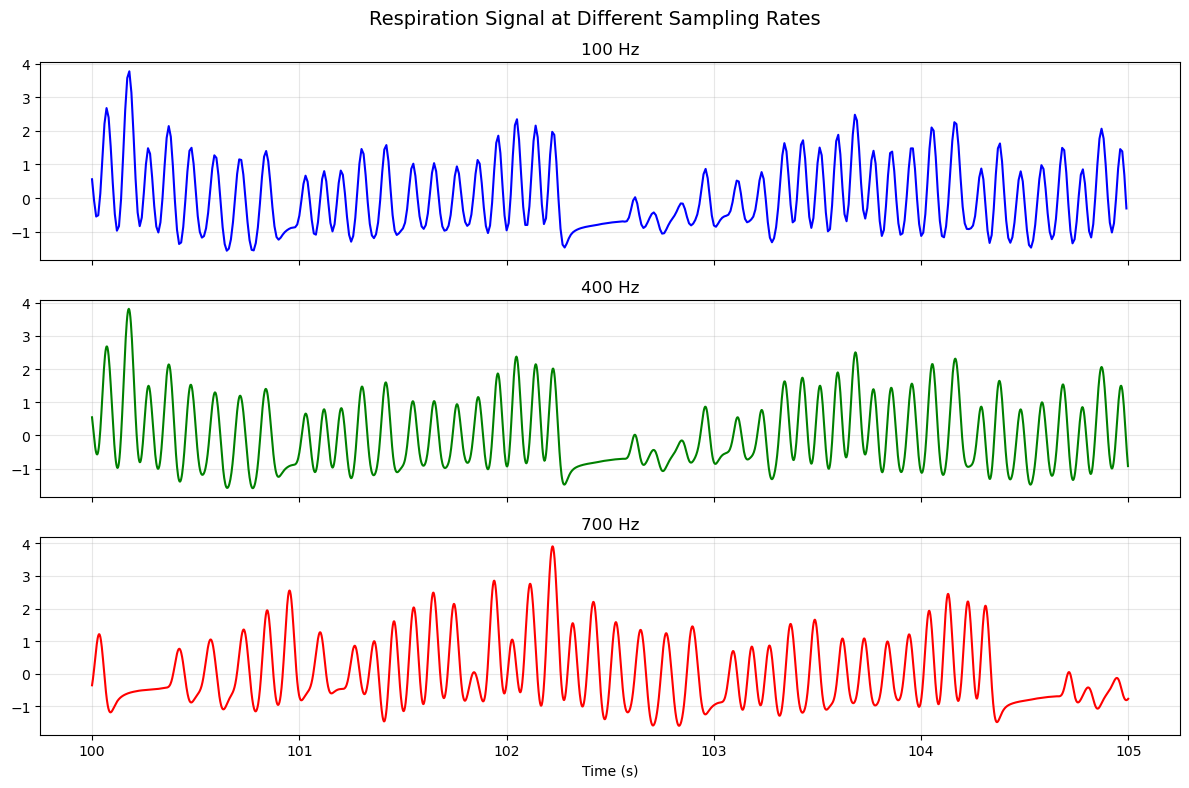

In [47]:
example_trial = list(resp_paths_interactions.values())[0]

plot_sampling_comparison(example_trial)

### Feature Extraction using Breathmetrics

In [ ]:
# ============================================================
# Main build loop:
#   - RI1/RI2  : bouts padded/cropped to 5 s, dropped if < 1 s
#   - BLRI     : random 5-s windows sampled as pseudo-bouts
# ============================================================

def build_feature_matrix_5s(
    resp_paths_interactions, boris_paths_valence,
    resp_paths_blri, rank_map,
    target_dur=5.0, min_dur=1.0,
    n_baseline_windows=10,
    pre_bout_window=2.0,
    data_type="rodentAirflow",
    target_srate=100,
    min_breaths_per_bout=2,
    baseline_seed=42,
    subject_only=False,
):
    all_rows = []

    # ── A. Interaction sessions (RI1 / RI2) ────────────────────
    for trial, h5_path in resp_paths_interactions.items():
        print(f"\n[Interaction] {trial}")

        signal, time, fs, meta = load_clean_resp_signal(h5_path, target_rate=target_srate)
        if signal is None:
            print("  ❌ Load failed"); continue

        # Signal Checks
        print("signal len:", len(signal))
        print("fs:", fs)
        print("nan count:", np.isnan(signal).sum())
        print("inf count:", np.isinf(signal).sum())
        print("min/max:", np.nanmin(signal), np.nanmax(signal))
        print("std:", np.nanstd(signal))
        print("first 10:", signal[:10])

        bm = fit_bm_session(signal, fs, data_type=data_type)
        if bm is None: continue
        print(f"  ✓ {len(bm.inhaleOnsets)} breaths detected")

        subj      = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank      = rank_map.get(subj, np.nan)

        if trial not in boris_paths_valence:
            print(f"  ⚠️  No BORIS for {trial}, skipping"); continue

        boris_df = load_clean_boris(boris_paths_valence[trial], subject_only=subject_only)
        if boris_df.empty:
            print(f"  ⚠️  Empty BORIS, skipping"); continue

        boris_df = standardize_bouts_to_target(boris_df, time[0], time[-1],
                                        target_dur=target_dur, min_dur=min_dur)
        n_dropped_dur = 0
        for _, bout in boris_df.iterrows():
            feats = extract_bout_features(bm, bout["Start"], bout["Stop"])
            if feats is None or feats["n_breaths"] < min_breaths_per_bout:
                n_dropped_dur += 1; continue

            pre_start = max(time[0], bout["Start"] - pre_bout_window)
            pre_feats = extract_bout_features(bm, pre_start, bout["Start"])
            pre_rate  = pre_feats["breathing_rate_hz"] if pre_feats else np.nan

            row = {
                "Behavior"        : bout.get("Behavior", np.nan),
                "Initiator"       : bout.get("Initiator", np.nan),
                "Start"           : bout["Start"],
                "Stop"            : bout["Stop"],
                "Duration"        : bout["Duration"],
                "PreBoutRespRate"  : pre_rate,
                "Trial"           : trial,
                "Subject"         : subj,
                "Condition"       : condition,
                "Rank"            : rank,
                "Type"            : "Interaction",
                "Label"           : np.nan,
            }
            row.update(feats)
            row["resp_rate_delta"] = (
                row["breathing_rate_hz"] - pre_rate
                if not np.isnan(pre_rate) else np.nan
            )
            all_rows.append(row)

        if n_dropped_dur:
            print(f"  → Dropped {n_dropped_dur} bouts (too few breaths after padding)")

    # ── B. Baseline sessions (BLRI) ────────────────────────────
    for trial, h5_path in resp_paths_blri.items():
        print(f"\n[Baseline]    {trial}")

        signal, time, fs, meta = load_clean_resp_signal(h5_path, target_rate=target_srate)
        if signal is None:
            print("  ❌ Load failed"); continue

        bm = fit_bm_session(signal, fs, data_type=data_type)
        if bm is None: continue
        print(f"  ✓ {len(bm.inhaleOnsets)} breaths detected")

        subj      = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank      = rank_map.get(subj, np.nan)

        windows = sample_baseline_windows(
            time, window_dur=target_dur,
            n_windows=n_baseline_windows, seed=baseline_seed
        )
        n_ok = 0
        for w_idx, (w_start, w_stop) in enumerate(windows):
            feats = extract_bout_features(bm, w_start, w_stop)
            if feats is None or feats["n_breaths"] < min_breaths_per_bout:
                continue

            row = {
                "Behavior"        : "Baseline",
                "Start"           : w_start,
                "Stop"            : w_stop,
                "Duration"        : w_stop - w_start,
                "PreBoutRespRate"  : np.nan,
                "Trial"           : trial,
                "Subject"         : subj,
                "Condition"       : condition,
                "Rank"            : rank,
                "Type"            : "Baseline",
                "Label"           : np.nan,
                "resp_rate_delta"  : np.nan,
            }
            row.update(feats)
            all_rows.append(row)
            n_ok += 1
        print(f"  ✓ {n_ok}/{len(windows)} baseline windows kept")

    # ── C. Assemble ────────────────────────────────────────────
    if not all_rows:
        print("\n⚠️  No rows collected."); return pd.DataFrame()

    master_df = pd.DataFrame(all_rows).reset_index(drop=True)

    master_df["breathing_rate_z"] = (
        master_df.groupby("Trial")["breathing_rate_hz"]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan)
    )

    print(f"\n✅ Feature matrix: {len(master_df)} rows × {len(master_df.columns)} cols")
    print(f"   Trials    : {master_df['Trial'].nunique()}")
    print(f"   Subjects  : {master_df['Subject'].nunique()}")
    print(f"   Type dist :\n{master_df['Type'].value_counts()}")
    if "Initiator" in master_df.columns:
        print(f"   Initiator dist :\n{master_df['Initiator'].value_counts()}")

    return master_df

In [ ]:
master_df_5s = build_feature_matrix_5s(
    resp_paths_interactions = resp_paths_interactions,
    boris_paths_valence     = boris_paths_valence,
    resp_paths_blri         = resp_paths_blri,
    rank_map                = rank_map,
    target_dur              = 5.0,
    min_dur                 = 0.5,
    n_baseline_windows      = 10,
    pre_bout_window         = 2.0,
    data_type               = "rodentAirflow",
    target_srate            = 400,
    min_breaths_per_bout    = 2,
)


[Interaction] RI1_3_6
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
signal len: 241309
fs: 400
nan count: 0
inf count: 0
min/max: -3156.867102857029 10588.63410486072
std: 858.8590672038366
first 10: [-467.88675514 -496.19362445 -525.68070149 -556.31412296 -587.02853624
 -616.16974673 -641.92086911 -662.60366276 -676.86850375 -683.78037763]
  ✓ 3902 breaths detected

[Interaction] RI2_3_6
original resp len: 12200094
original fs: 20000.0
duration_sec: 610.0047
expected duration from len/fs: 610.0047
signal len: 244002
fs: 400
nan count: 0
inf count: 0
min/max: -3807.9919642887703 12918.181040029714
std: 664.2060884060726
first 10: [-223.21616649 -206.90451895 -189.94693921 -171.54058131 -150.94238964
 -127.62227354 -101.34473094  -72.17481497  -40.43811851   -6.65785284]
  ✓ 2506 breaths detected

[Interaction] RI1_4_7
original resp len: 12583112
original fs: 20000.0
duration_sec: 629.1556
expected duration from len/fs: 

In [54]:
# Confirm all windows are ~5 s and types look right
print(master_df_5s["Duration"].describe())
print("\nType counts:", master_df_5s["Type"].value_counts().to_dict())
print("Behavior counts:\n", master_df_5s["Behavior"].value_counts())
print("Feature cols:", [c for c in master_df_5s.columns if c not in
    ["BoutID","Behavior","Initiator","Start","Stop","Duration","Label",
     "PreBoutRespRate","Trial","Subject","Condition","Rank",
     "Type","resp_rate_delta","breathing_rate_z"]])

count    3.770000e+02
mean     5.000000e+00
std      2.959965e-15
min      5.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: Duration, dtype: float64

Type counts: {'Interaction': 308, 'Baseline': 69}
Behavior counts:
 Behavior
body sniffing          144
facial sniffing         91
anogenital sniffing     73
Baseline                69
Name: count, dtype: int64
Feature cols: ['n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_breathing_rate', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol', 'cv_tidal_vol', 'minute_ventilation', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle'

In [55]:
master_df_5s.head()

,Behavior,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,Condition,Rank,Type,Label,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_breathing_rate,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol,cv_tidal_vol,minute_ventilation,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,resp_rate_delta,breathing_rate_z
0,facial sniffing,9.9830,14.9830,5.0,6.052963,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,50,10.129199,0.098724,0.252408,0.045750,0.398907,0.048000,0.376156,0.953125,1372.540171,-1148.885687,0.325553,44836.657875,37908.416042,82745.073917,0.467869,838141.317192,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.463411,0.486202,4.076236,1.099564
1,anogenital sniffing,13.0865,18.0865,5.0,11.224490,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,47,9.573361,0.104457,0.276190,0.046064,0.437737,0.055000,0.466195,0.837524,1275.456554,-1104.794307,0.419239,42718.638323,41938.300402,84656.938725,0.559841,810451.442527,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.440986,0.526535,-1.651129,0.627943
2,anogenital sniffing,23.7930,28.7930,5.0,10.282776,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,46,9.302326,0.107500,0.256962,0.045815,0.390194,0.056467,0.400761,0.811357,1252.621783,-988.921183,0.343064,40253.191896,38718.495254,78971.687151,0.510396,734620.345589,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.426188,0.525278,-0.980451,0.397973
3,body sniffing,25.6205,30.6205,5.0,9.078772,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,48,9.504550,0.105213,0.232184,0.045469,0.374539,0.055000,0.300940,0.826705,1205.830092,-983.261242,0.273101,38124.549813,37038.803618,75163.353431,0.433089,714393.854648,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.432160,0.522750,0.425778,0.569558
4,anogenital sniffing,26.8615,31.8615,5.0,9.718670,RI1_3_6,3_6,RI1,Dominant,Interaction,NaN,46,9.321595,0.107278,0.221671,0.046630,0.370468,0.056413,0.295647,0.826590,1243.425669,-998.704341,0.257380,40108.866724,38557.017808,78665.884532,0.419620,733291.518169,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.434670,0.525860,-0.397075,0.414323


In [56]:
nan_counts = master_df_5s.isna().sum()
nan_pct = master_df_5s.isna().mean() * 100

nan_summary = pd.DataFrame({
    "nan_count": nan_counts,
    "nan_percent": nan_pct
}).sort_values(by="nan_percent", ascending=False)

nan_summary

,nan_count,nan_percent
Label,377,100.000000
cv_inhale_pause_dur,303,80.371353
cv_exhale_pause_dur,146,38.726790
resp_rate_delta,72,19.098143
PreBoutRespRate,72,19.098143
breathing_rate_z,3,0.795756
exhale_pause_duty_cycle,0,0.000000
inhale_duty_cycle,0,0.000000
mean_exhale_pause_dur_sec,0,0.000000
pct_breaths_with_exhale_pause,0,0.000000


## Breathmetrics Respiration Features
- n_breaths: Total number of detected breaths (typically counted via inhale onsets).

- breathing_rate_hz: Number of breaths per second, computed from the average time between consecutive inhales.

- mean_ibi_sec: Average inter-breath interval (time between breaths), equal to the inverse of breathing rate.

- cv_breathing_rate: Coefficient of variation of breath timing, measuring variability in inter-breath intervals.

- mean_inhale_dur_sec: Average duration of inhalation phases across breaths.

- cv_inhale_dur: Variability (coefficient of variation) of inhale durations.

- mean_exhale_dur_sec: Average duration of exhalation phases across breaths.

- cv_exhale_dur: Variability (coefficient of variation) of exhale durations.

- ie_ratio: Ratio of inhale duration to exhale duration, reflecting breathing asymmetry.

- mean_peak_insp_flow: Average maximum airflow achieved during inhalation (peak inspiratory flow).

- mean_peak_exp_flow: Average maximum airflow during exhalation (peak expiratory flow, typically trough values).

- cv_peak_insp_flow: Variability of peak inspiratory flow across breaths.

- mean_inhale_vol: Average volume of air inhaled per breath (integral of airflow during inhale).

- mean_exhale_vol: Average volume of air exhaled per breath.

- mean_tidal_vol: Average total air displaced per breath (inhale + exhale volume).

- cv_tidal_vol: Variability of tidal volume across breaths.

- minute_ventilation: Total air volume per second (or minute if scaled), computed as breathing rate × tidal volume.

- pct_breaths_with_inhale_pause: Proportion of breaths that include a pause after inhalation.

- mean_inhale_pause_dur_sec: Average duration of pauses occurring after inhalation.

- cv_inhale_pause_dur: Variability of inhale pause durations.

- inhale_pause_duty_cycle: Fraction of each breathing cycle spent in inhale pause.

- pct_breaths_with_exhale_pause: Proportion of breaths that include a pause after exhalation.

- mean_exhale_pause_dur_sec: Average duration of pauses occurring after exhalation.

- cv_exhale_pause_dur: Variability of exhale pause durations.

- exhale_pause_duty_cycle: Fraction of each breathing cycle spent in exhale pause.

- inhale_duty_cycle: Fraction of each breathing cycle spent inhaling.

- exhale_duty_cycle: Fraction of each breathing cycle spent exhaling.

### Dropping bad recording | no behavior

In [57]:
# RI1_3_5
master_df_5s = master_df_5s[master_df_5s["Trial"] != "RI1_3_5"]
master_df_5s["Trial"].unique()

array(['RI1_3_6', 'RI2_3_6', 'RI1_4_7', 'RI2_4_7', 'RI1_2_3', 'RI2_2_3',
       'RI1_4_8', 'RI1_1_1', 'RI2_1_1', 'RI1_1_2', 'RI2_1_2', 'RI1_2_4',
       'RI2_2_4', 'RI2_3_5', 'BLRI_1_1', 'BLRI_1_2', 'BLRI_2_3',
       'BLRI_2_4', 'BLRI_3_6', 'BLRI_4_7', 'BLRI_4_8'], dtype=object)

Pickling

In [58]:
# master_df_5s.to_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features")
master_df_5s.to_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features-More")

### Quick Overview of Behavior by Recording

In [59]:
import pandas as pd

summary = []

for key, path in boris_paths_valence.items():
    try:
        df = pd.read_csv(path)
        cols = set(df.columns)

        summary.append({
            "session": key,
            "has_image_start": "Image index start" in cols,
            "has_image_stop": "Image index stop" in cols,
            "has_start_sec": "Start (s)" in cols,
            "has_stop_sec": "Stop (s)" in cols,
            "n_rows": len(df)
        })

    except Exception as e:
        summary.append({
            "session": key,
            "error": str(e)
        })

summary_df = pd.DataFrame(summary)
summary_df


,session,has_image_start,has_image_stop,has_start_sec,has_stop_sec,n_rows
0,RI1_3_6,True,True,True,True,37
1,RI2_3_6,True,True,True,True,109
2,RI1_4_7,True,True,True,True,37
3,RI2_4_7,True,True,True,True,108
4,RI1_2_3,True,True,True,True,44
5,RI2_2_3,True,True,True,True,102
6,RI1_4_8,True,True,True,True,55
7,RI2_4_8,True,True,True,True,113
8,RI1_1_1,False,False,True,True,92
9,RI2_1_1,False,False,True,True,37


### OG Feature Matrix no new features

#### Resp Features Present
- BoutRespRate
- PreBoutRespRate
- SessionRate
- BoutRespRate_pre_delta
- BoutRespRate_z

In [60]:
print("\n==============================")
print("Processing Valence (RI1/RI2)")
print("==============================")

try:
    master_df_valence = process_all_trials_bout_level(resp_paths_valence, boris_paths_valence, rank_map)
    print(f"✓ Valence processing complete: {len(master_df_valence)} rows")
except Exception as e:
    print(f"✗ Error processing valence data: {e}")
    print("Attempting to continue with available data...")
    master_df_valence = pd.DataFrame()


Processing Valence (RI1/RI2)
Processing RI1_3_6...
original resp len: 12065446
original fs: 20000.0
duration_sec: 603.2723
expected duration from len/fs: 603.2723
   → Filtered 4 short bouts
Processing RI2_3_6...
original resp len: 12200094
original fs: 20000.0
duration_sec: 610.0047
expected duration from len/fs: 610.0047
   → Filtered 12 short bouts
Processing RI1_4_7...
original resp len: 12583112
original fs: 20000.0
duration_sec: 629.1556
expected duration from len/fs: 629.1556
   → Filtered 3 short bouts
Processing RI2_4_7...
original resp len: 12129332
original fs: 20000.0
duration_sec: 606.4666
expected duration from len/fs: 606.4666
   → Filtered 1 short bouts
Processing RI1_2_3...
original resp len: 12058916
original fs: 20000.0
duration_sec: 602.9458
expected duration from len/fs: 602.9458
   → Filtered 18 short bouts
Processing RI2_2_3...
original resp len: 12184065
original fs: 20000.0
duration_sec: 609.20325
expected duration from len/fs: 609.20325
   → Filtered 3 short 

In [61]:
master_df_valence.columns

Index(['Behavior', 'Subject', 'Start', 'Stop', 'Duration', 'BoutRespRate', 'PreBoutRespRate', 'BoutID', 'Trial', 'Condition', 'Rank', 'SessionRate', 'Type', 'BoutRespRate_pre_delta', 'BoutRespRate_z'], dtype='object')

In [62]:
master_df_valence.head()

,Behavior,Subject,Start,Stop,Duration,BoutRespRate,PreBoutRespRate,BoutID,Trial,Condition,Rank,SessionRate,Type,BoutRespRate_pre_delta,BoutRespRate_z
0,facial sniffing,3_6,11.966,13.000,1.034,8.814815,9.167834,0,RI1_3_6,RI1,Dominant,8.07892,Interaction,-0.353019,-0.555753
1,anogenital sniffing,3_6,14.483,16.690,2.207,9.704521,9.766671,1,RI1_3_6,RI1,Dominant,8.07892,Interaction,-0.062151,0.729896
2,anogenital sniffing,3_6,25.034,27.552,2.518,9.152463,9.388105,2,RI1_3_6,RI1,Dominant,8.07892,Interaction,-0.235642,-0.067842
3,body sniffing,3_6,27.793,28.448,0.655,10.040404,9.167320,3,RI1_3_6,RI1,Dominant,8.07892,Interaction,0.873084,1.215257
4,anogenital sniffing,3_6,28.862,29.861,0.999,9.180884,8.654543,4,RI1_3_6,RI1,Dominant,8.07892,Interaction,0.526342,-0.026772


In [63]:
master_df_valence["Condition"].value_counts()

Condition
RI1     273
RI2      37
BLRI      7
Name: count, dtype: int64

#### Drop rows with Duration < 5 | Not doing that rn

In [64]:
len(master_df_valence)

317

In [65]:
# master_df_valence = master_df_valence[master_df_valence["Duration"] >= 5]
# print(f"After filtering Duration >= 5: {len(master_df_valence)} rows")